In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.inspection import permutation_importance

In [26]:
df_before_spliting=pd.read_csv("./ssm_all_features_extended.csv")

In [27]:
TRAIN_PATH = "./train.csv"
VALIDATION_PATH = "./validation.csv"
TEST_PATH = "./test.csv"

In [28]:
tca_train_df= pd.read_csv(TRAIN_PATH)
tca_validation_df= pd.read_csv(VALIDATION_PATH)
tca_test_df= pd.read_csv(TEST_PATH)

In [29]:
j1=pd.merge(tca_train_df, tca_test_df, on=["conv_id","turn_id"], how='inner')
j2=pd.merge(tca_train_df, tca_validation_df, on=["conv_id","turn_id"], how='inner')
j3=pd.merge(tca_validation_df, tca_test_df, on=["conv_id","turn_id"], how='inner')

assert len(j1) == 0
assert len(j2) == 0
assert len(j3) == 0

In [30]:
train_df = pd.merge(tca_train_df, df_before_spliting, on=["conv_id","turn_id"], how='inner')
validation_df = pd.merge(tca_validation_df, df_before_spliting, on=["conv_id","turn_id"], how='inner')
test_df = pd.merge(tca_test_df, df_before_spliting, on=["conv_id","turn_id"], how='inner')

In [31]:
columns_to_drop = set(tca_train_df.columns).difference(["conv_id", "turn_id"])

In [32]:
df_all=train_df.drop(columns=columns_to_drop)

In [33]:
df_all.head()

,conv_id,turn_id,0,1,2,3,4,5,6,7,...,1535,state_drift,state_input_distance,long_term_state_drift,state_similarity,state_input_similarity,long_term_state_similarity,mean_squared_change_short,mean_squared_change_long,y
0,0,0,-0.004938,0.010028,-0.009252,0.005573,0.004999,0.004853,-0.015082,-0.023915,...,0.027231,0.424472,1.060708,0.000000,0.000000,0.064875,1.000000,0.000235,0.000000,0
1,0,1,-0.005842,0.028222,-0.015452,-0.032046,0.014550,0.003275,-0.012755,-0.021501,...,0.008139,0.285567,1.122548,0.285567,0.808949,-0.028589,0.808949,0.000106,0.000106,1
2,0,2,0.002231,0.032334,-0.024924,-0.034721,0.016211,-0.005692,-0.002074,-0.026771,...,0.010325,0.240984,1.142455,0.377847,0.882606,-0.047110,0.684473,0.000076,0.000186,1
3,1,0,-0.015485,-0.014725,0.005911,0.019545,0.010477,-0.001654,-0.009771,-0.001021,...,0.006432,0.387274,1.077727,0.000000,0.000000,-0.014866,1.000000,0.000195,0.000000,1
4,4,0,0.015814,0.019572,0.004737,0.008828,-0.007281,0.001262,-0.002580,-0.013442,...,-0.007148,0.457524,1.116935,0.000000,0.000000,-0.041763,1.000000,0.000273,0.000000,0


In [34]:
vector_list= list(str(col) for col in range(768+768))
vector_list.append("conv_id")
vector_list.append("turn_id")
features_list = list(set(df_all.columns.tolist()).difference(set(vector_list)))

In [35]:
df_vectors = df_all[vector_list]

In [36]:
df = df_all[features_list]

In [37]:
df["label"]=df["y"]
df.drop(columns=["y"], inplace=True)

C:\Users\Karim Mahmoud\AppData\Local\Temp\ipykernel_3392\3066773331.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"]=df["y"]
C:\Users\Karim Mahmoud\AppData\Local\Temp\ipykernel_3392\3066773331.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["y"], inplace=True)


In [38]:
df 

,long_term_state_drift,state_drift,mean_squared_change_long,state_similarity,state_input_similarity,mean_squared_change_short,state_input_distance,long_term_state_similarity,label
0,0.000000,0.424472,0.000000,0.000000,0.064875,0.000235,1.060708,1.000000,0
1,0.285567,0.285567,0.000106,0.808949,-0.028589,0.000106,1.122548,0.808949,1
2,0.377847,0.240984,0.000186,0.882606,-0.047110,0.000076,1.142455,0.684473,1
3,0.000000,0.387274,0.000000,0.000000,-0.014866,0.000195,1.077727,1.000000,1
4,0.000000,0.457524,0.000000,0.000000,-0.041763,0.000273,1.116935,1.000000,0
...,...,...,...,...,...,...,...,...,...
1947,0.000000,0.448419,0.000000,0.000000,-0.000796,0.000262,1.096264,1.000000,0
1948,0.359841,0.359841,0.000169,0.671529,-0.014446,0.000169,1.098020,0.671529,0
1949,0.422414,0.232671,0.000232,0.875392,0.016844,0.000070,1.101766,0.587448,0
1950,0.336179,0.253268,0.000147,0.851450,-0.023633,0.000084,1.101139,0.712542,0


In [39]:
feature_names=df.columns.tolist()
unique_labels = df["label"].unique()

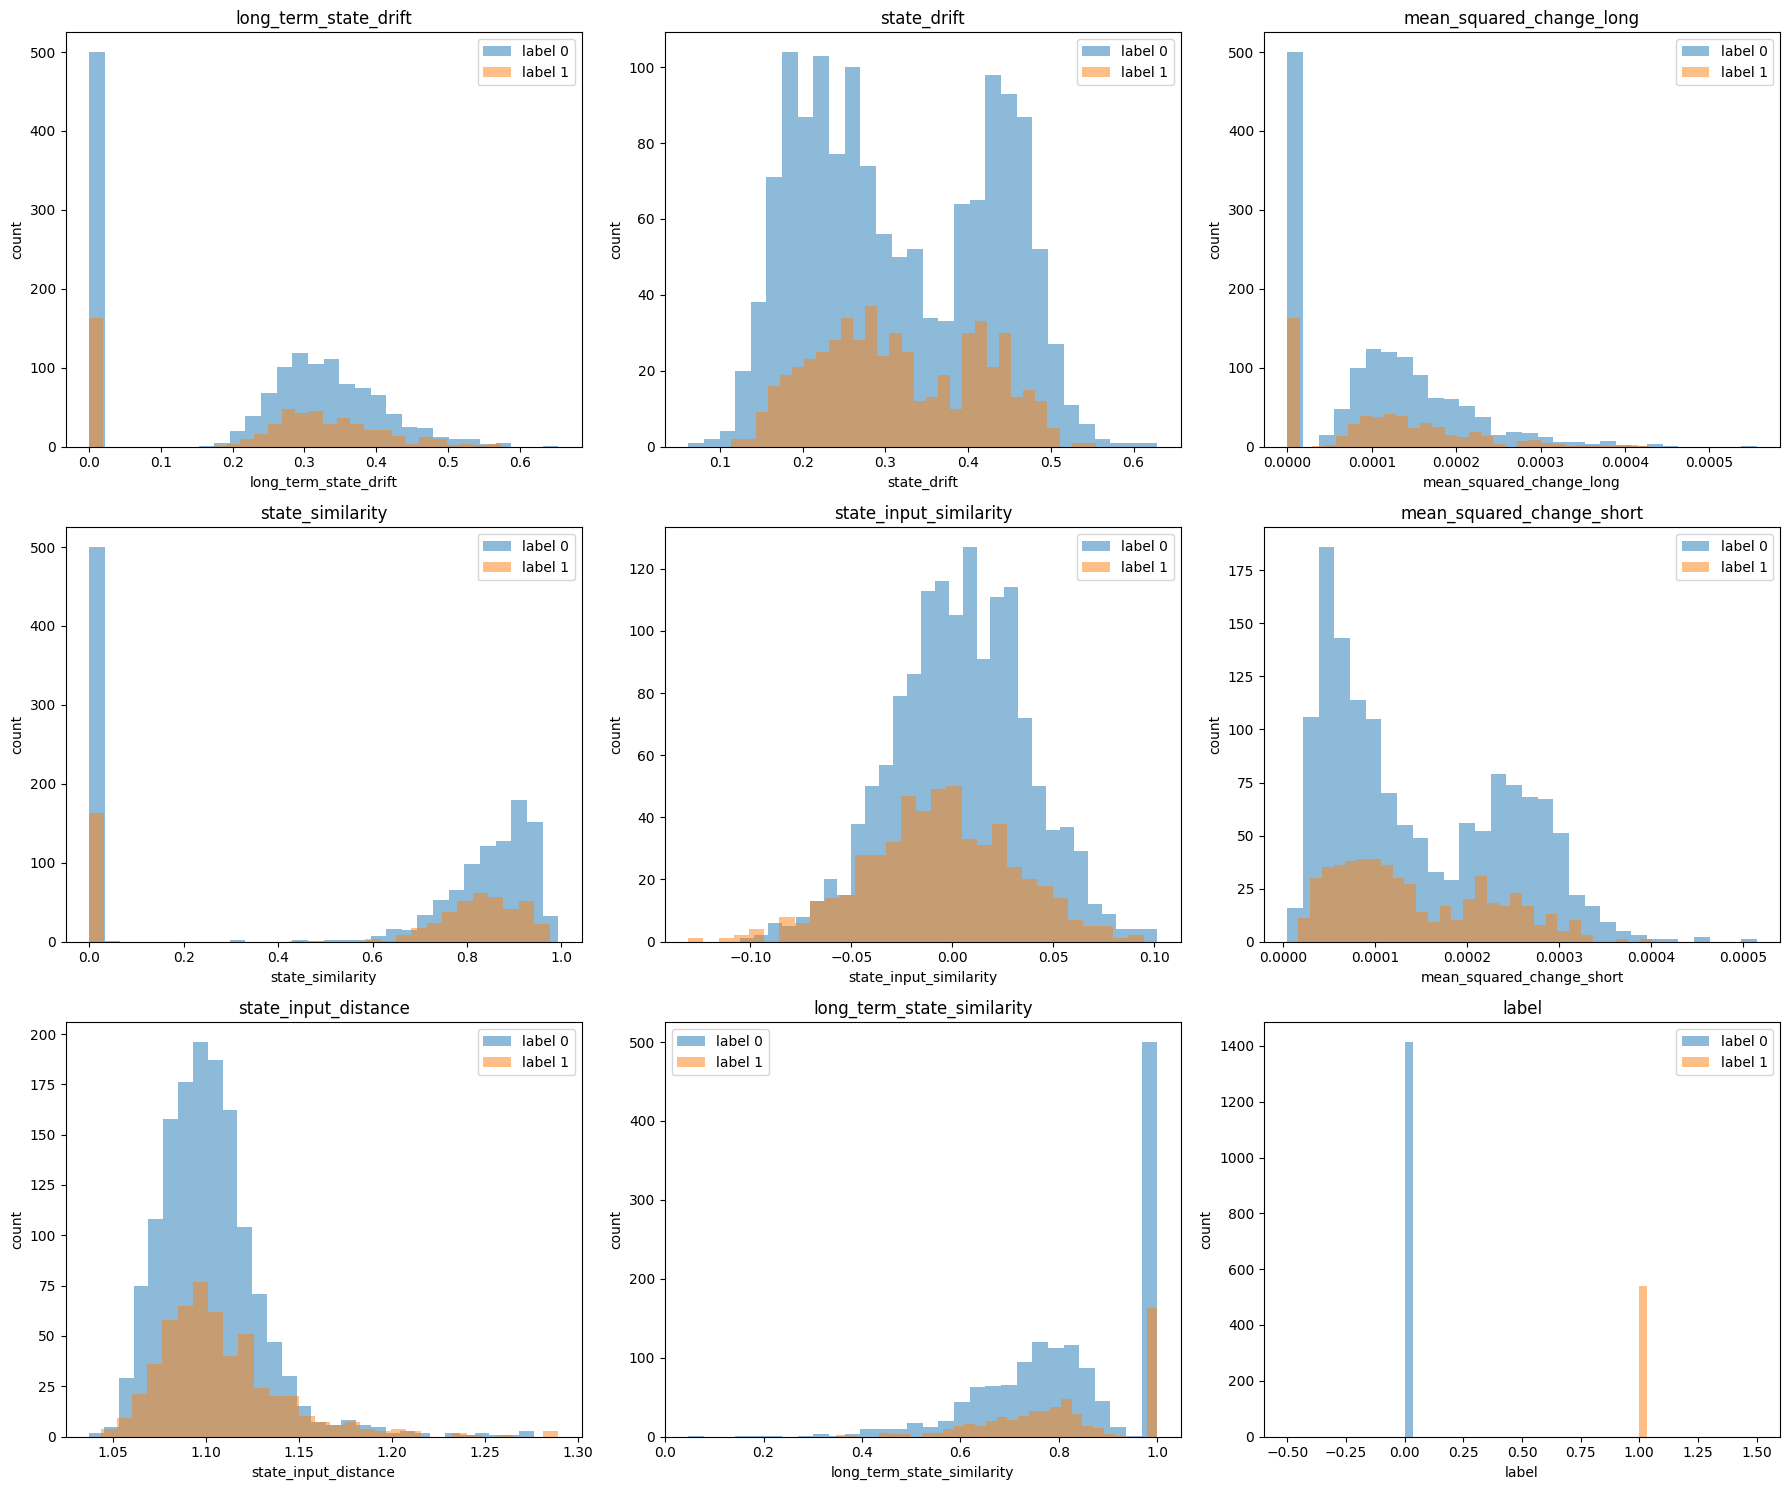

In [40]:
n_cols = 3
n_rows = int(np.ceil(len(feature_names) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    ax = axes[i]

    for lbl in unique_labels:
        subset = df[df["label"] == lbl][feature]
        ax.hist(subset, bins=30, alpha=0.5, label=f"label {lbl}")

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("count")
    ax.legend()

# remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [41]:
feature_names.pop()

'label'

In [42]:
feature_names

['long_term_state_drift',
 'state_drift',
 'mean_squared_change_long',
 'state_similarity',
 'state_input_similarity',
 'mean_squared_change_short',
 'state_input_distance',
 'long_term_state_similarity']

In [43]:
all_features = {}

for f in feature_names:
    orig = df[f].copy()
    all_features[f"{f}_orig"] = orig

    x = orig.copy()

    if x.min() <= 0:
        x = x - x.min() + 1e-6

    all_features[f"{f}_log"] = np.log(x)
    all_features[f"{f}_sqrt"] = np.sqrt(x)
    all_features[f"{f}_boxcox"], _ = stats.boxcox(x)

In [44]:
df_trans = pd.DataFrame(all_features)
df_trans["label"] = df["label"]

In [45]:
df_trans.head()

,long_term_state_drift_orig,long_term_state_drift_log,long_term_state_drift_sqrt,long_term_state_drift_boxcox,state_drift_orig,state_drift_log,state_drift_sqrt,state_drift_boxcox,mean_squared_change_long_orig,mean_squared_change_long_log,...,mean_squared_change_short_boxcox,state_input_distance_orig,state_input_distance_log,state_input_distance_sqrt,state_input_distance_boxcox,long_term_state_similarity_orig,long_term_state_similarity_log,long_term_state_similarity_sqrt,long_term_state_similarity_boxcox,label
0,0.000000,-13.815511,0.001000,-5.579636,0.424472,-0.856908,0.651515,-0.691900,0.000000,-13.815511,...,-3.416035,1.060708,0.058937,1.029907,0.040927,1.000000,0.000000e+00,1.000000,0.000000e+00,0
1,0.285567,-1.253276,0.534385,-1.136020,0.285567,-1.253280,0.534384,-0.921694,0.000106,-9.140976,...,-3.498170,1.122548,0.115601,1.059504,0.059208,0.808949,-2.120188e-01,0.899416,-1.736780e-01,1
2,0.377847,-0.973263,0.614694,-0.901520,0.240984,-1.423026,0.490901,-1.006551,0.000186,-8.584956,...,-3.528500,1.142455,0.133179,1.068857,0.062607,0.684473,-3.791064e-01,0.827329,-2.680257e-01,1
3,0.000000,-13.815511,0.001000,-5.579636,0.387274,-0.948624,0.622313,-0.749344,0.000000,-13.815511,...,-3.436567,1.077727,0.074854,1.038136,0.047509,1.000000,1.192093e-07,1.000000,1.192093e-07,1
4,0.000000,-13.815511,0.001000,-5.579636,0.457524,-0.781926,0.676405,-0.642864,0.000000,-13.815511,...,-3.398508,1.116935,0.110588,1.056851,0.058086,1.000000,1.192093e-07,1.000000,1.192093e-07,0


In [46]:
df_trans.columns.tolist()

['long_term_state_drift_orig',
 'long_term_state_drift_log',
 'long_term_state_drift_sqrt',
 'long_term_state_drift_boxcox',
 'state_drift_orig',
 'state_drift_log',
 'state_drift_sqrt',
 'state_drift_boxcox',
 'mean_squared_change_long_orig',
 'mean_squared_change_long_log',
 'mean_squared_change_long_sqrt',
 'mean_squared_change_long_boxcox',
 'state_similarity_orig',
 'state_similarity_log',
 'state_similarity_sqrt',
 'state_similarity_boxcox',
 'state_input_similarity_orig',
 'state_input_similarity_log',
 'state_input_similarity_sqrt',
 'state_input_similarity_boxcox',
 'mean_squared_change_short_orig',
 'mean_squared_change_short_log',
 'mean_squared_change_short_sqrt',
 'mean_squared_change_short_boxcox',
 'state_input_distance_orig',
 'state_input_distance_log',
 'state_input_distance_sqrt',
 'state_input_distance_boxcox',
 'long_term_state_similarity_orig',
 'long_term_state_similarity_log',
 'long_term_state_similarity_sqrt',
 'long_term_state_similarity_boxcox',
 'label']

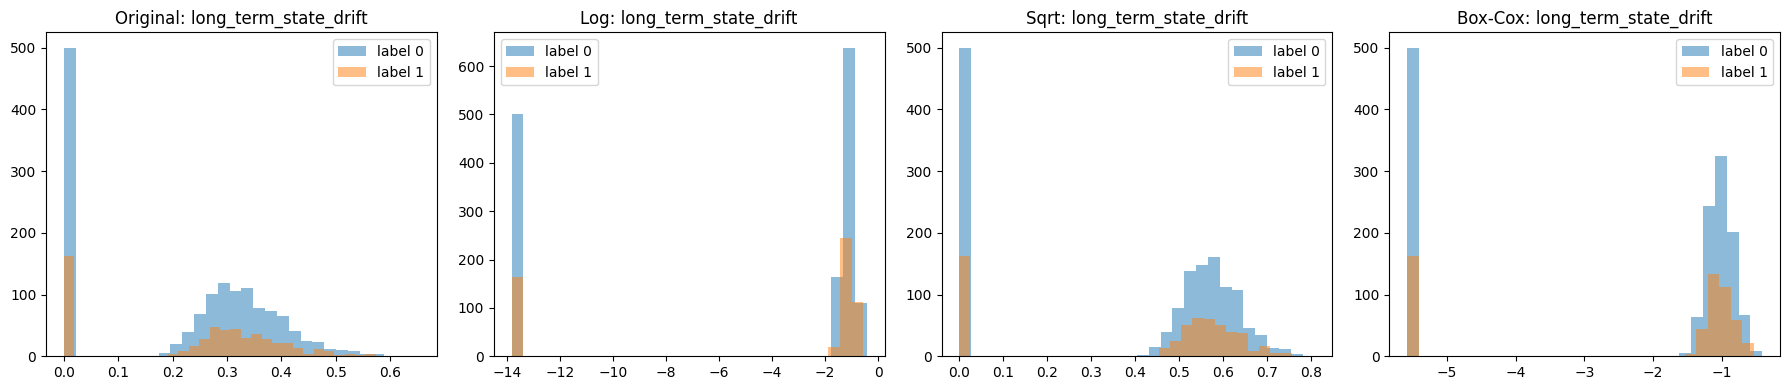

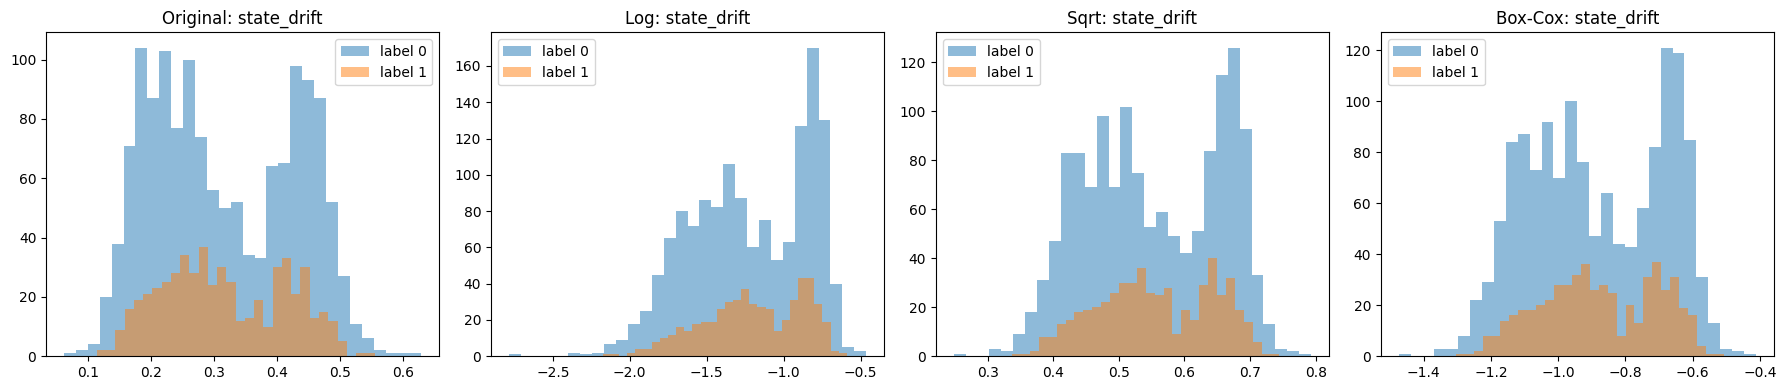

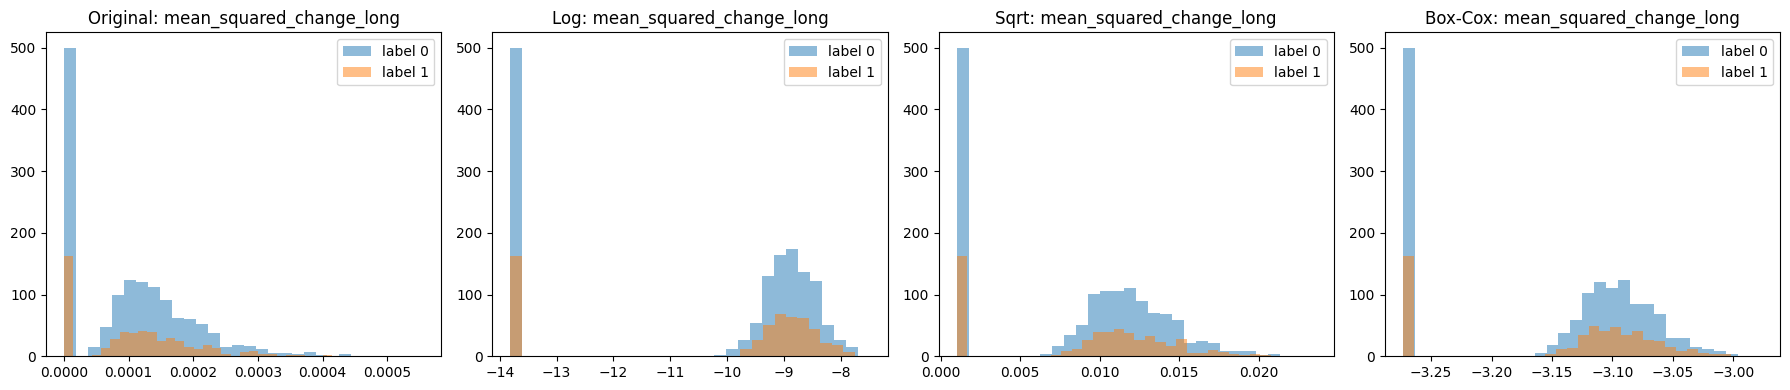

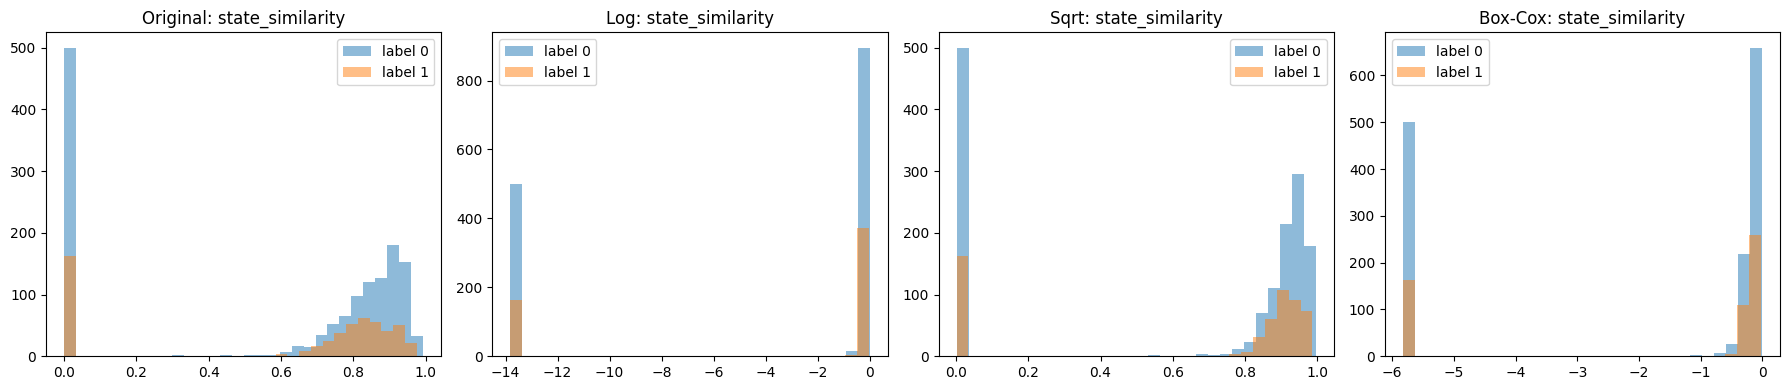

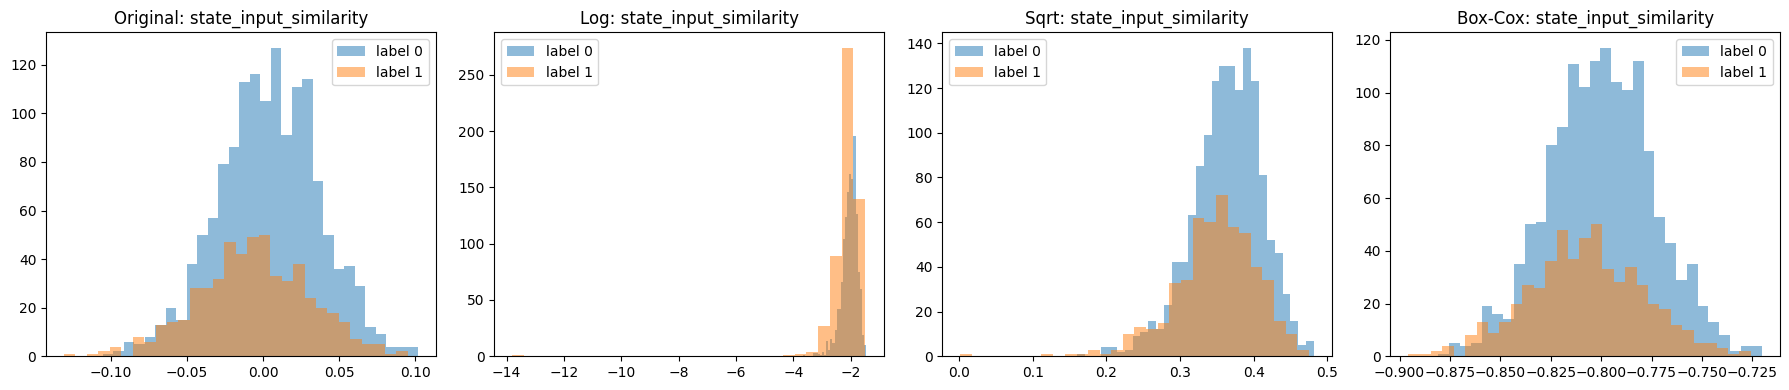

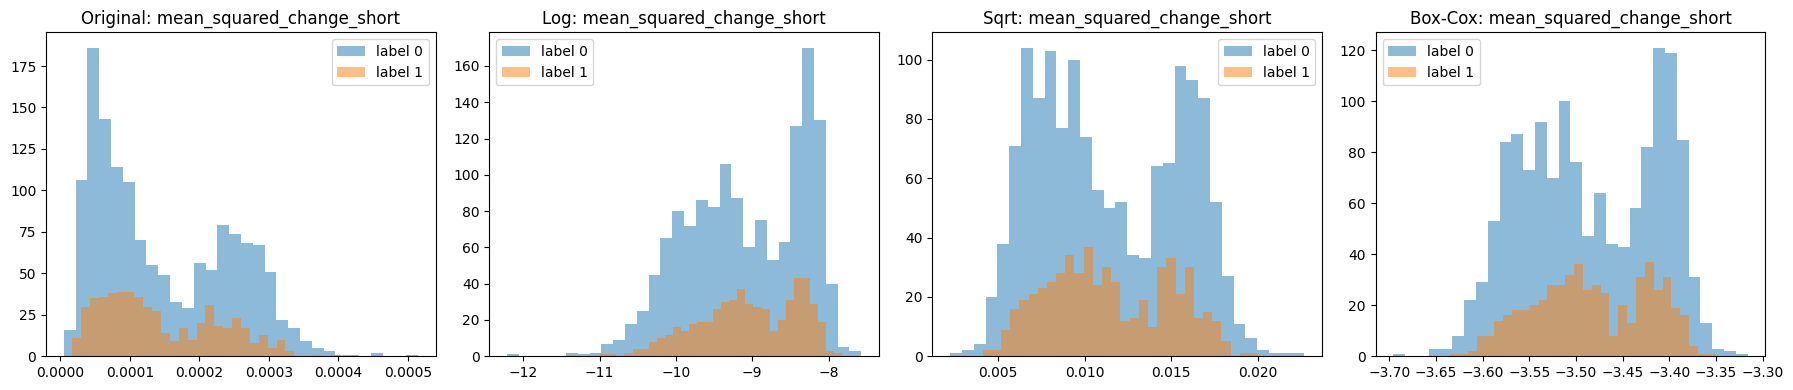

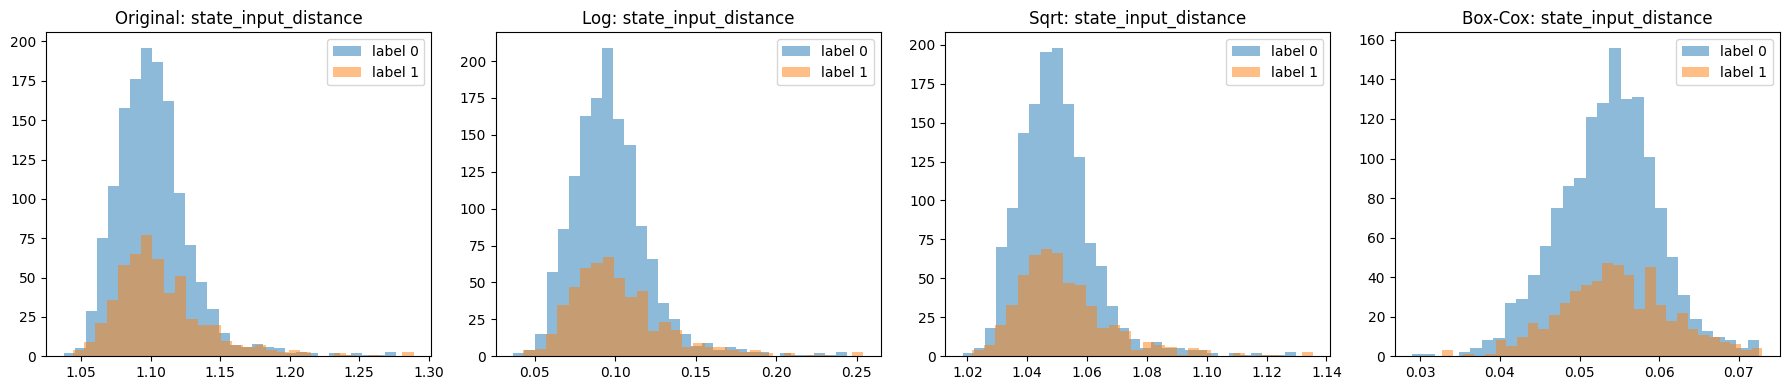

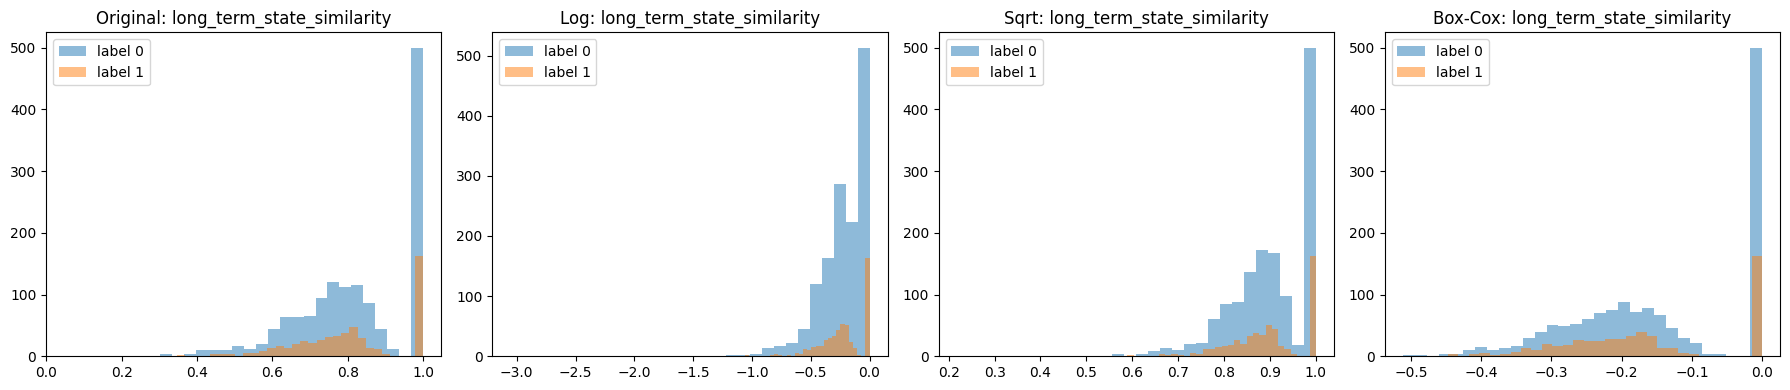

In [47]:
for feature in feature_names:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    for lbl in df_trans["label"].unique():
        subset = df_trans[df_trans["label"] == lbl][feature+"_orig"]
        axes[0].hist(subset, bins=30, alpha=0.5, label=f"label {lbl}")
        subset_log = df_trans[df_trans["label"] == lbl][f"{feature}_log"]
        axes[1].hist(subset_log, bins=30, alpha=0.5, label=f"label {lbl}")
        subset_sqrt = df_trans[df_trans["label"] == lbl][f"{feature}_sqrt"]
        axes[2].hist(subset_sqrt, bins=30, alpha=0.5, label=f"label {lbl}")
        subset_boxcox = df_trans[df_trans["label"] == lbl][f"{feature}_boxcox"]
        axes[3].hist(subset_boxcox, bins=30, alpha=0.5, label=f"label {lbl}")

    axes[0].set_title(f"Original: {feature}")
    axes[1].set_title(f"Log: {feature}")
    axes[2].set_title(f"Sqrt: {feature}")
    axes[3].set_title(f"Box-Cox: {feature}")

    for ax in axes:
        ax.legend()

    plt.tight_layout()
    plt.show()

In [48]:
df_trans = pd.DataFrame(all_features)
df_trans["label"] = df["label"]

In [49]:
df_trans

,long_term_state_drift_orig,long_term_state_drift_log,long_term_state_drift_sqrt,long_term_state_drift_boxcox,state_drift_orig,state_drift_log,state_drift_sqrt,state_drift_boxcox,mean_squared_change_long_orig,mean_squared_change_long_log,...,mean_squared_change_short_boxcox,state_input_distance_orig,state_input_distance_log,state_input_distance_sqrt,state_input_distance_boxcox,long_term_state_similarity_orig,long_term_state_similarity_log,long_term_state_similarity_sqrt,long_term_state_similarity_boxcox,label
0,0.000000,-13.815511,0.001000,-5.579636,0.424472,-0.856908,0.651515,-0.691900,0.000000,-13.815511,...,-3.416035,1.060708,0.058937,1.029907,0.040927,1.000000,0.000000e+00,1.000000,0.000000e+00,0
1,0.285567,-1.253276,0.534385,-1.136020,0.285567,-1.253280,0.534384,-0.921694,0.000106,-9.140976,...,-3.498170,1.122548,0.115601,1.059504,0.059208,0.808949,-2.120188e-01,0.899416,-1.736780e-01,1
2,0.377847,-0.973263,0.614694,-0.901520,0.240984,-1.423026,0.490901,-1.006551,0.000186,-8.584956,...,-3.528500,1.142455,0.133179,1.068857,0.062607,0.684473,-3.791064e-01,0.827329,-2.680257e-01,1
3,0.000000,-13.815511,0.001000,-5.579636,0.387274,-0.948624,0.622313,-0.749344,0.000000,-13.815511,...,-3.436567,1.077727,0.074854,1.038136,0.047509,1.000000,1.192093e-07,1.000000,1.192093e-07,1
4,0.000000,-13.815511,0.001000,-5.579636,0.457524,-0.781926,0.676405,-0.642864,0.000000,-13.815511,...,-3.398508,1.116935,0.110588,1.056851,0.058086,1.000000,1.192093e-07,1.000000,1.192093e-07,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1947,0.000000,-13.815511,0.001000,-5.579636,0.448419,-0.802026,0.669641,-0.656196,0.000000,-13.815511,...,-3.403273,1.096264,0.091908,1.047026,0.053179,1.000000,1.192093e-07,1.000000,1.192093e-07,0
1948,0.359841,-1.022089,0.599869,-0.943167,0.359841,-1.022092,0.599868,-0.793430,0.000169,-8.682060,...,-3.452325,1.098020,0.093509,1.047864,0.053649,0.671529,-3.981975e-01,0.819469,-2.769783e-01,0
1949,0.422414,-0.861766,0.649935,-0.805194,0.232671,-1.458131,0.482360,-1.023187,0.000232,-8.363032,...,-3.534446,1.101766,0.096914,1.049650,0.054615,0.587448,-5.319672e-01,0.766452,-3.311778e-01,0
1950,0.336179,-1.090108,0.579810,-1.000648,0.253268,-1.373306,0.503258,-0.982464,0.000147,-8.817240,...,-3.519891,1.101139,0.096345,1.049352,0.054457,0.712542,-3.389165e-01,0.844122,-2.480546e-01,0


In [50]:
corr_with_label = df_trans.corr(method="spearman")["label"].drop("label")

In [51]:
best_features = []

for f in feature_names:
    candidates = {
        "orig": corr_with_label.get(f"{f}_orig", 0),
        "log": corr_with_label.get(f"{f}_log", 0),
        "sqrt": corr_with_label.get(f"{f}_sqrt", 0),
        "boxcox": corr_with_label.get(f"{f}_boxcox", 0),
    }

    best_variant = max(candidates, key=lambda k: abs(candidates[k]))
    best_features.append(f"{f}_{best_variant}")

In [52]:
best_features

['long_term_state_drift_orig',
 'state_drift_orig',
 'mean_squared_change_long_orig',
 'state_similarity_orig',
 'state_input_similarity_orig',
 'mean_squared_change_short_orig',
 'state_input_distance_orig',
 'long_term_state_similarity_orig']

In [54]:
from sklearn.ensemble import RandomForestClassifier

X = df_trans[best_features]
y = df_trans["label"]

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)

importances = model.feature_importances_

feature_importance = sorted(
    zip(X.columns, importances),
    key=lambda x: x[1],
    reverse=True
)

for f, imp in feature_importance:
    print(f"{f}: {imp:.4f}")

state_input_similarity_orig: 0.1711
state_input_distance_orig: 0.1684
state_drift_orig: 0.1457
mean_squared_change_short_orig: 0.1413
state_similarity_orig: 0.0994
long_term_state_similarity_orig: 0.0966
long_term_state_drift_orig: 0.0915
mean_squared_change_long_orig: 0.0861


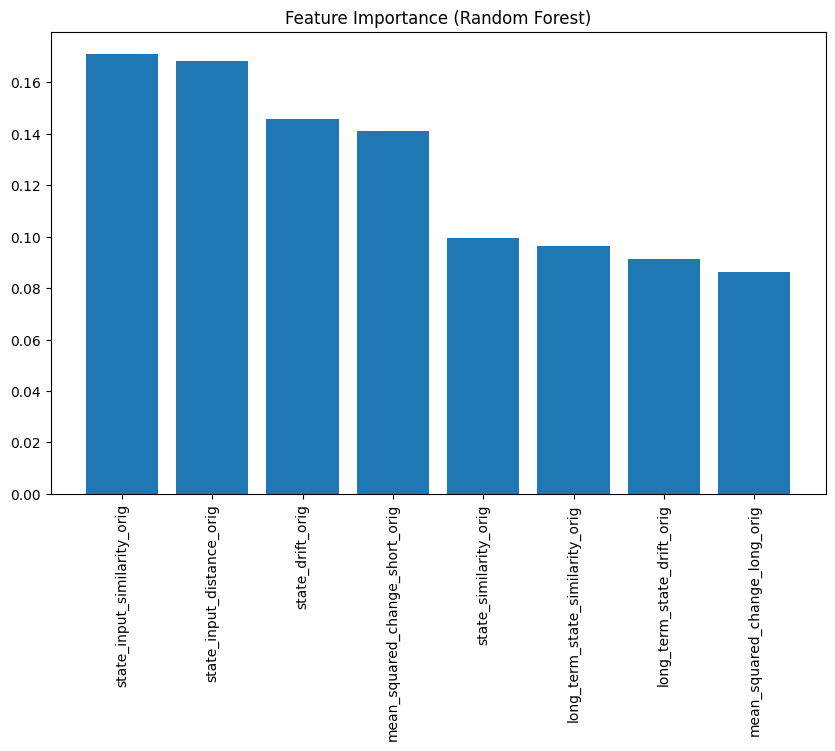

In [55]:
names = [f for f, _ in feature_importance]
values = [imp for _, imp in feature_importance]

plt.figure(figsize=(10, 6))
plt.bar(names, values)
plt.xticks(rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [57]:
result = permutation_importance(
    model, X, y,
    n_repeats=10,
    random_state=42
)

In [58]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
})

importances = importances.sort_values("importance", ascending=False)
print(importances)

                           feature  importance       std
4      state_input_similarity_orig    0.127254  0.005026
6        state_input_distance_orig    0.101844  0.002242
7  long_term_state_similarity_orig    0.054764  0.003647
1                 state_drift_orig    0.052561  0.002703
5   mean_squared_change_short_orig    0.049078  0.003960
3            state_similarity_orig    0.034170  0.002613
0       long_term_state_drift_orig    0.031865  0.002709
2    mean_squared_change_long_orig    0.023105  0.002375


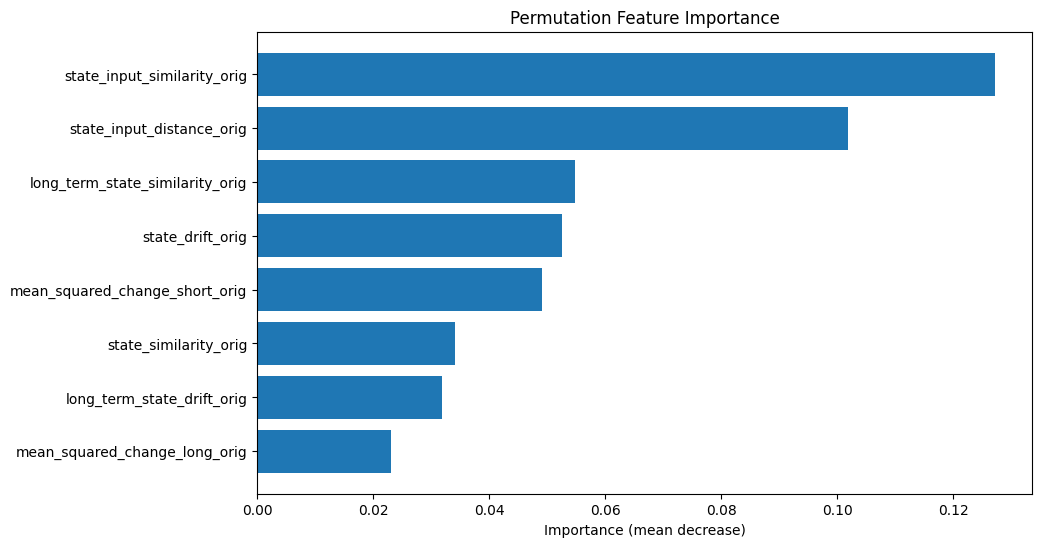

In [59]:
plt.figure(figsize=(10, 6))
plt.barh(importances["feature"], importances["importance"])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance")
plt.xlabel("Importance (mean decrease)")
plt.show()

In [60]:
feature_names

['long_term_state_drift',
 'state_drift',
 'mean_squared_change_long',
 'state_similarity',
 'state_input_similarity',
 'mean_squared_change_short',
 'state_input_distance',
 'long_term_state_similarity']

In [61]:
selected_features = [
    'state_input_similarity',
    'state_drift',
    'state_input_distance',
    'long_term_state_similarity',
    'mean_squared_change_short'
]

In [62]:
df_final=df_all[vector_list+ selected_features  + ["conv_id","turn_id"]+["y"]]

In [63]:
df_final

,0,1,2,3,4,5,6,7,8,9,...,conv_id,turn_id,state_input_similarity,state_drift,state_input_distance,long_term_state_similarity,mean_squared_change_short,conv_id,turn_id,y
0,-0.004938,0.010028,-0.009252,0.005573,0.004999,0.004853,-0.015082,-0.023915,0.014907,0.005539,...,0,0,0.064875,0.424472,1.060708,1.000000,0.000235,0,0,0
1,-0.005842,0.028222,-0.015452,-0.032046,0.014550,0.003275,-0.012755,-0.021501,0.033707,0.023255,...,0,1,-0.028589,0.285567,1.122548,0.808949,0.000106,0,1,1
2,0.002231,0.032334,-0.024924,-0.034721,0.016211,-0.005692,-0.002074,-0.026771,0.027421,0.023131,...,0,2,-0.047110,0.240984,1.142455,0.684473,0.000076,0,2,1
3,-0.015485,-0.014725,0.005911,0.019545,0.010477,-0.001654,-0.009771,-0.001021,0.006958,-0.011655,...,1,0,-0.014866,0.387274,1.077727,1.000000,0.000195,1,0,1
4,0.015814,0.019572,0.004737,0.008828,-0.007281,0.001262,-0.002580,-0.013442,0.018371,0.019792,...,4,0,-0.041763,0.457524,1.116935,1.000000,0.000273,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1947,0.012246,0.027351,-0.008980,-0.003279,0.006228,0.002713,0.004879,-0.030176,-0.034079,0.023652,...,1102,0,-0.000796,0.448419,1.096264,1.000000,0.000262,1102,0,0
1948,0.006430,0.024574,0.011456,-0.004979,0.005864,0.009597,-0.007297,-0.022292,-0.009493,0.020766,...,1102,1,-0.014446,0.359841,1.098020,0.671529,0.000169,1102,1,0
1949,-0.001728,0.025578,0.004210,-0.001403,-0.001000,0.003655,-0.015018,-0.024756,-0.017481,0.035664,...,1102,2,0.016844,0.232671,1.101766,0.587448,0.000070,1102,2,0
1950,0.004882,0.022310,-0.001374,-0.001648,0.005781,0.004602,-0.004118,-0.035176,-0.015884,0.023807,...,1102,3,-0.023633,0.253268,1.101139,0.712542,0.000084,1102,3,0


In [277]:
df_final.to_csv("./../data/ssm_final_features_extended.csv", index=False)